# Scoring d'attrition

**Objectif :**
1. Comparer les 5 modèles (Logit, Random Forest, XGBoost, LightGBM, MLP) par validation croisée (5-fold, AUC-ROC).
2. Sélectionner automatiquement les **3 meilleurs modèles**.
3. Entraîner ces 3 modèles sur l'ensemble de la base et calculer un **score d'attrition par individu**.
4. Calculer les **valeurs SHAP** pour chaque modèle retenu et générer, pour chaque individu,
   les **3 facteurs de risque explicatifs** (`risk1`, `risk2`, `risk3`)
5. Exporter un fichier Excel avec un onglet de comparaison, un onglet de scoring par modèle retenu,
   et un onglet de synthèse.


## 1. Configuration et chargement des données

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    brier_score_loss, roc_curve,
    precision_score, recall_score, accuracy_score, f1_score
)

import xgboost as xgb
import lightgbm as lgb
import shap

RANDOM_STATE = 42
N_SPLITS = 5
ID_COL = "employee"    
TARGET_COL = "Y"

all_drivers1 = pd.read_csv("all_drivers_bon2.csv", sep=",", encoding="utf-8")
print(f"Base chargee : {all_drivers1.shape[0]:,} individus, {all_drivers1.shape[1]} variables")
all_drivers1.head()


Base chargee : 4,355 individus, 31 variables


,employee,department,job_code,date_hired,date_limite,est_parti,salaire_cumule,miles_cumules,stops_cumules,heures_cumulees,...,miles_cumules_par_semaine,stops_cumules_par_semaine,heures_cumulees_par_semaine,Y,duree,anciennete_nouv,nb_indiscipline,watchlist_score_actuel,nb_inspection,nb_voe_requested_t
0,1038133,96604,1807,2008-02-14,2026-04-20,False,29700908.38,8759.58,828120.0,799496.26,...,0.535820,50.655738,48.904836,0,6640.0,[Plus de 5 ans],0,2.0,3,0
1,1043319,96164,1807,2008-02-19,2026-04-20,False,2078150.76,768.60,69300.0,50660.28,...,0.593056,53.472222,39.089722,0,6635.0,[Plus de 5 ans],0,0.0,0,0
2,1051196,96544,1807,2008-03-15,2024-12-05,True,966449.40,364.56,35280.0,20826.68,...,0.520800,50.400000,29.752400,1,6109.0,[Plus de 5 ans],0,0.0,0,0
3,1054036,96604,1807,2008-04-07,2026-04-20,False,1539673.48,210.70,21500.0,40974.27,...,0.153125,15.625000,29.777812,0,6587.0,[Plus de 5 ans],1,22.0,1,0
4,106214,96494,1807,1998-10-09,2026-04-20,False,8322483.65,2868.45,182065.0,209820.00,...,0.678923,43.092308,49.661538,0,10055.0,[Plus de 5 ans],0,12.0,1,0


## 2. Variables du modèle

Reprise exacte des variables utilisées dans la section "Modèle logistique / RF / XGBoost / LightGBM / MLP"
du notebook d'origine, pour une comparaison équitable des 5 modèles.

In [48]:
CAT_COLS = [
    "job_code",
    "department",
    "anciennete_nouv"
]

NUM_COLS = [
    "nombre_de_pay_gaps",
    "nb_voe_requested_t",
    "watchlist_score_actuel",
    "avg_weekly_miles_actuel",
    "salaire_cumule",
    "nb_indiscipline",
    "nb_inspection"
]

FEATURE_COLS = NUM_COLS + CAT_COLS
print("Variables utilisees :", FEATURE_COLS)


Variables utilisees : ['nombre_de_pay_gaps', 'nb_voe_requested_t', 'watchlist_score_actuel', 'avg_weekly_miles_actuel', 'salaire_cumule', 'nb_indiscipline', 'nb_inspection', 'job_code', 'department', 'anciennete_nouv']


## 3. Comparaison des 5 modèles

=== Comparaison des modeles (moyenne sur 5 folds) ===
      Modele  AUC_moy  AUC_std   AP_moy   AP_std  LogLoss_moy  Brier_moy  Accuracy_moy  Precision_moy  Rappel_moy   F1_moy
     XGBoost 0.886085 0.010002 0.840261 0.014770     0.381616   0.121681      0.819288       0.779664    0.654899 0.710961
    LightGBM 0.883853 0.008618 0.836284 0.011694     0.384273   0.122978      0.816303       0.774375    0.648816 0.705480
RandomForest 0.865452 0.018049 0.810506 0.026186     0.459389   0.146945      0.791504       0.974938    0.396448 0.562526
         MLP 0.835722 0.016063 0.771316 0.027725     0.774047   0.163701      0.791963       0.713715    0.648115 0.678181
       Logit 0.822473 0.015708 0.760286 0.020496     0.466344   0.150038      0.777956       0.747171    0.523644 0.614945


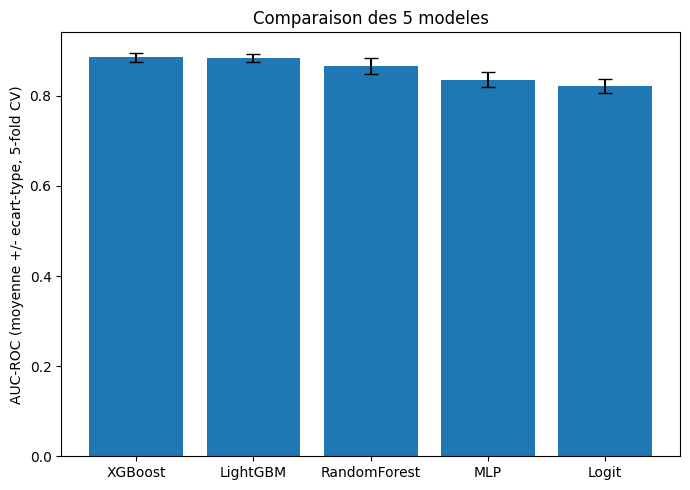

In [49]:
import warnings
from sklearn.exceptions import ConvergenceWarning

def build_preprocessor(num_cols, cat_cols, drop_first):
  
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(
            drop="first" if drop_first else None,
            sparse_output=False,
            min_frequency=0.01,
            handle_unknown="infrequent_if_exist" if drop_first else "ignore"
        ), cat_cols),
    ])


def clean_names(names):
    # XGBoost / LightGBM n'acceptent pas certains caracteres dans les noms de colonnes
    return [re.sub(r"[\[\]<>\s]", "_", n) for n in names]


# On filtre proprement le warning de l'encodeur et de convergence du MLP pour garder un terminal propre
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.preprocessing._encoders")

MODELS = {
    "Logit": {
        "estimator": lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "drop_first": True,
        "needs_named_df": False,
        "family": "linear",
    },
    "RandomForest": {
        "estimator": lambda: RandomForestClassifier(
            n_estimators=500, max_depth=6, min_samples_leaf=20,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        "drop_first": False,
        "needs_named_df": False,
        "family": "tree",
    },
    "XGBoost": {
        "estimator": lambda: xgb.XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_STATE
        ),
        "drop_first": False,
        "needs_named_df": True,
        "family": "tree",
    },
    "LightGBM": {
        "estimator": lambda: lgb.LGBMClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbose=-1
        ),
        "drop_first": False,
        "needs_named_df": True,
        "family": "tree",
    },
    "MLP": {
        # Solution : Augmentation de max_iter à 1500 itérations pour laisser le temps au modèle de converger
        "estimator": lambda: MLPClassifier(
            hidden_layer_sizes=(32, 16), activation="relu",
            alpha=1e-3, max_iter=1500, random_state=RANDOM_STATE
        ),
        "drop_first": True,
        "needs_named_df": False,
        "family": "mlp",
    },
}

def evaluate_models_cv(df, num_cols, cat_cols, target_col=TARGET_COL,
                        models=MODELS, n_splits=N_SPLITS,
                        random_state=RANDOM_STATE, seuil=0.5):

    X_raw = df[num_cols + cat_cols].copy()
    Y = df[target_col].copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []
    roc_curves = {}

    for name, cfg in models.items():
        fold_rows = []
        for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X_raw, Y)):
            X_train, X_test = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
            Y_train, Y_test = Y.iloc[tr_idx], Y.iloc[te_idx]

            preprocessor = build_preprocessor(num_cols, cat_cols, cfg["drop_first"])
            X_train_enc = preprocessor.fit_transform(X_train)
            X_test_enc = preprocessor.transform(X_test)

            # Optimisation MLP : On applique un StandardScaler global sur TOUTES les features (y compris après OneHot)
            if cfg["family"] == "mlp":
                scaler_global = StandardScaler(with_mean=False) # avec_mean=False préserve la sparsité si applicable
                X_train_enc = scaler_global.fit_transform(X_train_enc)
                X_test_enc = scaler_global.transform(X_test_enc)

            if cfg["needs_named_df"]:
                feat_names = clean_names(
                    num_cols + list(
                        preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
                    )
                )
                X_train_enc = pd.DataFrame(X_train_enc, columns=feat_names)
                X_test_enc = pd.DataFrame(X_test_enc, columns=feat_names)

            model = cfg["estimator"]()
            model.fit(X_train_enc, Y_train)
            pred = model.predict_proba(X_test_enc)[:, 1]
            pred_label = (pred >= seuil).astype(int)

            fold_rows.append({
                "AUC": roc_auc_score(Y_test, pred),
                "AP": average_precision_score(Y_test, pred),
                "LogLoss": log_loss(Y_test, pred),
                "Brier": brier_score_loss(Y_test, pred),
                "Accuracy": accuracy_score(Y_test, pred_label),
                "Precision": precision_score(Y_test, pred_label, zero_division=0),
                "Rappel": recall_score(Y_test, pred_label, zero_division=0),
                "F1": f1_score(Y_test, pred_label, zero_division=0),
            })

            if fold_i == 0:
                fpr, tpr, _ = roc_curve(Y_test, pred)
                roc_curves[name] = (fpr, tpr, roc_auc_score(Y_test, pred))

        fm = pd.DataFrame(fold_rows)
        results.append({
            "Modele": name,
            "AUC_moy": fm["AUC"].mean(), "AUC_std": fm["AUC"].std(),
            "AP_moy": fm["AP"].mean(), "AP_std": fm["AP"].std(),
            "LogLoss_moy": fm["LogLoss"].mean(),
            "Brier_moy": fm["Brier"].mean(),
            "Accuracy_moy": fm["Accuracy"].mean(),
            "Precision_moy": fm["Precision"].mean(),
            "Rappel_moy": fm["Rappel"].mean(),
            "F1_moy": fm["F1"].mean(),
        })

    results_df = pd.DataFrame(results).sort_values("AUC_moy", ascending=False).reset_index(drop=True)
    return results_df, roc_curves


results_df, roc_curves = evaluate_models_cv(all_drivers1, NUM_COLS, CAT_COLS)

print("=== Comparaison des modeles (moyenne sur 5 folds) ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(7, 5))
plt.bar(results_df["Modele"], results_df["AUC_moy"], yerr=results_df["AUC_std"], capsize=5)
plt.ylabel("AUC-ROC (moyenne +/- ecart-type, 5-fold CV)")
plt.title("Comparaison des 5 modeles")
plt.tight_layout()
plt.show()


## 4. Sélection automatique des 3 meilleurs modèles

Le classement se fait sur l'AUC moyen (5-fold CV). Les 3 premiers modèles du tableau
ci-dessus sont retenus pour la suite (entraînement final + scoring + SHAP).

In [50]:
TOP3 = results_df["Modele"].head(3).tolist()
print("Les 3 modeles retenus :", TOP3)

Les 3 modeles retenus : ['XGBoost', 'LightGBM', 'RandomForest']


## 5. Entraînement final des 3 modèles retenus (sur toute la base)

Pour le scoring individuel, on entraîne chaque modèle retenu sur un split train/test stratifié, puis on **applique le modèle à l'ensemble de la base** afin d'obtenir un score pour chaque chauffeur.

In [51]:
def entrainer_modele_final(df, num_cols, cat_cols, model_name, models=MODELS,
                            target_col=TARGET_COL, random_state=RANDOM_STATE, test_size=0.25):
    cfg = models[model_name]

    X_full = df[num_cols + cat_cols].copy()
    Y_full = df[target_col].copy()

    X_train, X_test, Y_train, Y_test = train_test_split(
        X_full, Y_full, test_size=test_size, random_state=random_state, stratify=Y_full
    )

    preprocessor = build_preprocessor(num_cols, cat_cols, cfg["drop_first"])
    preprocessor.fit(X_train)

    X_train_enc = preprocessor.transform(X_train)
    X_test_enc = preprocessor.transform(X_test)
    X_full_enc = preprocessor.transform(X_full)   

    feat_names = clean_names(
        num_cols + list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols))
    )

    X_train_enc = pd.DataFrame(X_train_enc, columns=feat_names, index=X_train.index)
    X_test_enc = pd.DataFrame(X_test_enc, columns=feat_names, index=X_test.index)
    X_full_enc = pd.DataFrame(X_full_enc, columns=feat_names, index=X_full.index)

    model = cfg["estimator"]()
    model.fit(X_train_enc, Y_train)

    pred_test = model.predict_proba(X_test_enc)[:, 1]
    auc_test = roc_auc_score(Y_test, pred_test)
    print(f"[{model_name}] AUC sur le test set = {auc_test:.3f}")

    score_full = model.predict_proba(X_full_enc)[:, 1]

    return {
        "model_name": model_name,
        "family": cfg["family"],
        "model": model,
        "preprocessor": preprocessor,
        "feat_names": feat_names,
        "X_full_enc": X_full_enc,
        "score_full": score_full,
    }

modeles_entraines = {
    name: entrainer_modele_final(all_drivers1, NUM_COLS, CAT_COLS, name)
    for name in TOP3
}


[XGBoost] AUC sur le test set = 0.897
[LightGBM] AUC sur le test set = 0.896
[RandomForest] AUC sur le test set = 0.862


## 6. Valeurs SHAP pour chaque modèle retenu

- Modèles à arbres (Random Forest, XGBoost, LightGBM) : `shap.TreeExplainer` .
- Régression logistique : `shap.LinearExplainer`.
- Réseau de neurones (MLP) : `shap.KernelExplainer`.

In [52]:
import numpy as np
import pandas as pd
import shap

def calculer_shap(entry, X_background=None, nsamples_kernel=100):
    model = entry["model"]
    X_full_enc = entry["X_full_enc"]
    family = entry["family"]

    if family == "tree":
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_full_enc)
        
 
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
       
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

    elif family == "linear":
        explainer = shap.LinearExplainer(model, X_full_enc)
        shap_values = explainer.shap_values(X_full_enc)
        
        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

    elif family == "mlp":
        background = shap.sample(X_full_enc, 100, random_state=RANDOM_STATE)

        def predict_proba_classe_1(x):
            return model.predict_proba(x)[:, 1]

        explainer = shap.KernelExplainer(predict_proba_classe_1, background)
        shap_values = explainer.shap_values(X_full_enc, nsamples=nsamples_kernel)

    else:
        raise ValueError(f"Famille de modele inconnue : {family}")

    return pd.DataFrame(shap_values, columns=entry["feat_names"], index=X_full_enc.index)


shap_par_modele = {name: calculer_shap(entry) for name, entry in modeles_entraines.items()}
for name, df_shap in shap_par_modele.items():
    print(f"SHAP calcule pour {name} : {df_shap.shape}")


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP calcule pour XGBoost : (4355, 47)
SHAP calcule pour LightGBM : (4355, 47)
SHAP calcule pour RandomForest : (4355, 47)


## 7. Traduction des variables en facteurs de risque lisibles

Dictionnaire de templates : chaque variable (ou modalité one-hot) est associée à une phrase
en langage clair, construite à partir de la **valeur brute** de l'individu (pas la valeur SHAP,
qui sert uniquement à ordonner l'importance).

In [ ]:
import numpy as np

def _fmt_num(x, decimals=0):
    try:
        if pd.isna(x) if 'pd' in globals() else isinstance(x, str):
            return str(x)
        return f"{x:,.{decimals}f}".replace(",", " ")
    except Exception:
        return str(x)


def template_nombre_de_pay_gaps(val_brute):
    if val_brute is None or (isinstance(val_brute, float) and np.isnan(val_brute)):
        return "Nombre de semaines avec écart de paie : inconnu"
    return f"{int(val_brute)} semaine(s) avec ecart de paie"

def template_nb_actions(val_brute):
    if val_brute is None or (isinstance(val_brute, float) and np.isnan(val_brute)):
        return "Nombre d'actions RH enregistrées : inconnu"
    return f"{int(val_brute)} action(s) RH enregistree(s)"

def template_nb_voe_requested_t(val_brute):
    if val_brute is None or (isinstance(val_brute, float) and np.isnan(val_brute)):
        return "Demande(s) de VOE : inconnu"
    return f"{int(val_brute)} demande(s) de verification d'emploi (VOE)"

def template_change_last_30_days_actuel(val_brute):
    return f"Changement recent (30 derniers jours) : indice {_fmt_num(val_brute, 2)}"

def template_avg_weekly_miles_actuel(val_brute):
    return f"Moyenne hebdomadaire de {_fmt_num(val_brute)} miles parcourus"

def template_avg_weekly_wage_actuel(val_brute):
    return f"Salaire hebdomadaire moyen de {_fmt_num(val_brute)} $"

def template_salaire_cumule(val_brute):
    return f"Salaire cumule de {_fmt_num(val_brute)} $"

def template_anciennete_nouv(modalite, val_brute):
    return f"Anciennete : {modalite}"

def template_department(modalite, val_brute):
    return f"Departement {modalite}"

def template_job_code(modalite, val_brute):
    return f"Poste {modalite}"


TEMPLATES_NUM = {
    "nombre_de_pay_gaps": template_nombre_de_pay_gaps,
    "nb_actions": template_nb_actions,
    "nb_voe_requested_t": template_nb_voe_requested_t,
    "change_last_30_days_actuel": template_change_last_30_days_actuel,
    "avg_weekly_miles_actuel": template_avg_weekly_miles_actuel,
    "avg_weekly_wage_actuel": template_avg_weekly_wage_actuel,
    "salaire_cumule": template_salaire_cumule,
}

TEMPLATES_CAT_PREFIX = {
    "anciennete_nouv": template_anciennete_nouv,
    "department": template_department,
    "job_code": template_job_code,
}


def variable_source_et_modalite(feature_name):
    """Retrouve, à partir d'un nom de colonne encodée (ex: 'department_96584'),
    la variable brute d'origine et la modalité associée."""
    if feature_name in TEMPLATES_NUM:
        return feature_name, None
    for prefix in TEMPLATES_CAT_PREFIX:
        if feature_name.startswith(prefix + "_"):
            modalite = feature_name[len(prefix) + 1:]
            return prefix, modalite
    return feature_name, None


def phrase_facteur(feature_name, row_brute):
    var, modalite = variable_source_et_modalite(feature_name)
    
    valeur = row_brute.get(var, None)
    
    if var in TEMPLATES_NUM:
        # Au cas où la valeur manquante n'a pas été interceptée
        val_pass = valeur if valeur is not None else np.nan
        return TEMPLATES_NUM[var](val_pass)
        
    if var in TEMPLATES_CAT_PREFIX:
        val_pass = valeur if valeur is not None else np.nan
        return TEMPLATES_CAT_PREFIX[var](modalite, val_pass)
        
    return f"{feature_name} = {valeur if valeur is not None else ''}"

## 8. Construction du tableau de scoring par individu

Pour chaque modèle retenu :
- `Score` = probabilité prédite d'attrition (0 à 1)
- `risk1`, `risk2`, `risk3` = les 3 variables dont la contribution SHAP est la plus fortement
  positive pour cet individu (celles qui poussent le score vers le risque), traduites en phrase claire.

In [54]:
def construire_table_scoring(df_source, entry, df_shap, id_col=ID_COL, target_col=TARGET_COL, n_risks=3):
    score_full = entry["score_full"]
    feat_names = entry["feat_names"]

    # Sécurité Indexation : On convertit score_full en Series Pandas alignée sur l'index de X_full_enc 
    X_index = entry["X_full_enc"].index
    if not isinstance(score_full, pd.Series):
        scores_ser = pd.Series(score_full, index=X_index)
    else:
        scores_ser = score_full

    lignes = []
    for idx in df_shap.index:
        row_shap = df_shap.loc[idx]
        
        # Sécurité : On récupère la ligne brute.
        raw_loc = df_source.loc[idx]
        row_brute = raw_loc.iloc[0] if isinstance(raw_loc, pd.DataFrame) else raw_loc

        # 1. Extraction des SHAP values positives (facteurs de risque)
        positives = row_shap[row_shap > 0].sort_values(ascending=False)
        top_feats = positives.index[:n_risks].tolist()
        
        # Génération des phrases explicatives
        phrases = [phrase_facteur(f, row_brute) for f in top_feats]
        
        # Remplissage si moins de n_risks facteurs positifs
        while len(phrases) < n_risks:
            phrases.append("-")

        # 2. Construction de la ligne de base
        ligne = {
            id_col: row_brute[id_col],
            # Alignement sécurisé du score
            "Score": round(float(scores_ser.loc[idx]), 4),
            # MODIFICATION : Ajout de la vraie valeur de Y (0 ou 1)
            "Statut_Reel (Y)": int(row_brute[target_col]) if target_col in row_brute else np.nan
        }
        
        # Ajout des colonnes de risque dynamiques
        for i, phrase in enumerate(phrases, start=1):
            ligne[f"risk{i}"] = phrase

        # 3. Variables brutes de contexte
        ligne["anciennete_nouv"] = row_brute.get("anciennete_nouv", "")
        ligne["nombre_de_pay_gaps"] = row_brute.get("nombre_de_pay_gaps", "")
        ligne["salaire_cumule"] = row_brute.get("salaire_cumule", "")
        ligne["rate_vs_dc_moyen"] = row_brute.get("rate_vs_dc_moyen", "")

        lignes.append(ligne)

    # Création du DataFrame final trié du plus risqué au moins risqué
    table = pd.DataFrame(lignes).sort_values("Score", ascending=False).reset_index(drop=True)
    return table


tables_scoring = {
    name: construire_table_scoring(all_drivers1, modeles_entraines[name], shap_par_modele[name])
    for name in TOP3
}

for name, table in tables_scoring.items():
    print(f"\n=== Scoring — {name} (extrait, top 5) ===")
    display(table.head(5))



=== Scoring — XGBoost (extrait, top 5) ===


,employee,Score,Statut_Reel (Y),risk1,risk2,risk3,anciennete_nouv,nombre_de_pay_gaps,salaire_cumule,rate_vs_dc_moyen
0,3263835,0.9955,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Moyenne hebdomadaire de 1 miles parcourus,[31-365j],0,61250.08,0.729249
1,3248052,0.9949,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 123 813 $,[31-365j],0,123813.00,0.910250
2,3242855,0.9947,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Moyenne hebdomadaire de 1 miles parcourus,[31-365j],0,29891.25,0.697335
3,3606557,0.9946,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 543 806 $,[31-365j],0,543806.46,0.993261
4,3343747,0.9946,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 139 761 $,[31-365j],0,139761.42,0.919133



=== Scoring — LightGBM (extrait, top 5) ===


,employee,Score,Statut_Reel (Y),risk1,risk2,risk3,anciennete_nouv,nombre_de_pay_gaps,salaire_cumule,rate_vs_dc_moyen
0,3390542,0.9982,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 584 556 $,[31-365j],52,584555.66,0.980167
1,3376922,0.9979,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 544 272 $,[31-365j],69,544271.54,0.860951
2,3467496,0.9977,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 988 528 $,[31-365j],0,988527.56,0.709266
3,3467445,0.9973,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Departement 96804,[31-365j],0,251755.68,1.354475
4,3269081,0.9972,1,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 736 408 $,[31-365j],0,736408.40,0.536325



=== Scoring — RandomForest (extrait, top 5) ===


,employee,Score,Statut_Reel (Y),risk1,risk2,risk3,anciennete_nouv,nombre_de_pay_gaps,salaire_cumule,rate_vs_dc_moyen
0,3544443,0.7662,1,watchlist_score_actuel = 0.0,Anciennete : _31-365j_,Anciennete : _366j_a_5ans_,[31-365j],0,440027.25,0.949935
1,3590837,0.7654,1,watchlist_score_actuel = 0.0,Anciennete : _31-365j_,Anciennete : _366j_a_5ans_,[31-365j],0,427608.25,0.977618
2,3559062,0.7646,1,watchlist_score_actuel = 0.0,Anciennete : _31-365j_,Anciennete : _366j_a_5ans_,[31-365j],0,248482.71,0.885209
3,3590807,0.7644,1,watchlist_score_actuel = 0.0,Anciennete : _31-365j_,Anciennete : _366j_a_5ans_,[31-365j],0,214267.20,0.555326
4,3386090,0.7636,1,watchlist_score_actuel = 0.0,Anciennete : _31-365j_,Anciennete : _366j_a_5ans_,[31-365j],0,221650.58,0.582301


## 9. Table de synthèse

Un score par modèle retenu pour chaque individu, plus les facteurs de risque du modèle
le plus performant (celui classé n°1 en AUC moyen).

In [55]:
meilleur_modele = TOP3[0]

synthese = all_drivers1[[ID_COL, TARGET_COL]].copy()
synthese = synthese.rename(columns={TARGET_COL: "Statut_Reel (Y)"})

for name in TOP3:
    score_map = dict(zip(all_drivers1[ID_COL], modeles_entraines[name]["score_full"]))
    synthese[f"Score_{name}"] = synthese[ID_COL].map(score_map)

# 3. Calcul du score moyen pour stabiliser la prédiction
synthese["Score_moyen_3_modeles"] = synthese[[f"Score_{n}" for n in TOP3]].mean(axis=1)

table_meilleur = tables_scoring[meilleur_modele][[ID_COL, "risk1", "risk2", "risk3"]]
synthese = synthese.merge(table_meilleur, on=ID_COL, how="left")

synthese = synthese.sort_values("Score_moyen_3_modeles", ascending=False).reset_index(drop=True)

print(f"Facteurs de risque affiches : issus du modele le plus performant ({meilleur_modele})")
synthese.head(10)


Facteurs de risque affiches : issus du modele le plus performant (XGBoost)


,employee,Statut_Reel (Y),Score_XGBoost,Score_LightGBM,Score_RandomForest,Score_moyen_3_modeles,risk1,risk2,risk3
0,3606557,1,0.994598,0.996171,0.761169,0.917313,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 543 806 $
1,3280129,1,0.993524,0.995946,0.761412,0.916961,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Departement 96164
2,3467446,1,0.993450,0.995958,0.759729,0.916379,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 487 623 $
3,3544443,1,0.989112,0.993220,0.766224,0.916185,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 440 027 $
4,3564064,1,0.992777,0.995591,0.759848,0.916072,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Anciennete : _366j_a_5ans_
5,3590837,1,0.987945,0.992913,0.765439,0.915432,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Anciennete : _366j_a_5ans_
6,3470688,1,0.992297,0.995748,0.758121,0.915389,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Moyenne hebdomadaire de 0 miles parcourus
7,3390542,1,0.994435,0.998228,0.753250,0.915304,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 584 556 $
8,3590740,1,0.991856,0.994219,0.759430,0.915168,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 581 466 $
9,3525450,1,0.991772,0.995062,0.758489,0.915107,Anciennete : _31-365j_,watchlist_score_actuel = 0.0,Salaire cumule de 564 131 $


## 10. Export Excel

Un onglet de comparaison des 5 modèles, un onglet de scoring détaillé par modèle retenu,
et un onglet de synthèse.

In [56]:
with pd.ExcelWriter("scoring_attrition.xlsx", engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="Comparaison_5_modeles", index=False)
    synthese.to_excel(writer, sheet_name="Synthese_top3", index=False)
    for name, table in tables_scoring.items():
        sheet_name = f"Scoring_{name}"[:31]
        table.to_excel(writer, sheet_name=sheet_name, index=False)

print("Export termine : scoring_attrition.xlsx")


Export termine : scoring_attrition.xlsx
